In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل ملف البيانات
df = pd.read_csv('tayseer_services.csv')
df['month'] = pd.to_datetime(df['month'])

print("تم تحميل البيانات بنجاح:")
df.head()

تم تحميل البيانات بنجاح:


,month,region,service_category,channel,transactions,unique_users,digital_adoption_pct,avg_completion_min,cost_per_txn_sar,csat,sla_met_pct,complaints
0,2021-07-01,Al-Baha,Business & Licensing,Branch,5727,4745,33.4,117.0,51.88,3.05,80.7,10
1,2021-07-01,Al-Baha,Business & Licensing,Call Center,2575,1708,33.4,31.5,24.11,3.57,93.2,2
2,2021-07-01,Al-Baha,Business & Licensing,Mobile App,1936,721,33.4,13.7,6.26,4.13,96.2,1
3,2021-07-01,Al-Baha,Business & Licensing,Web Portal,2425,1221,33.4,19.4,8.63,3.85,94.9,3
4,2021-07-01,Al-Baha,Education & Training,Branch,7443,5923,37.0,29.4,39.00,3.55,84.4,7


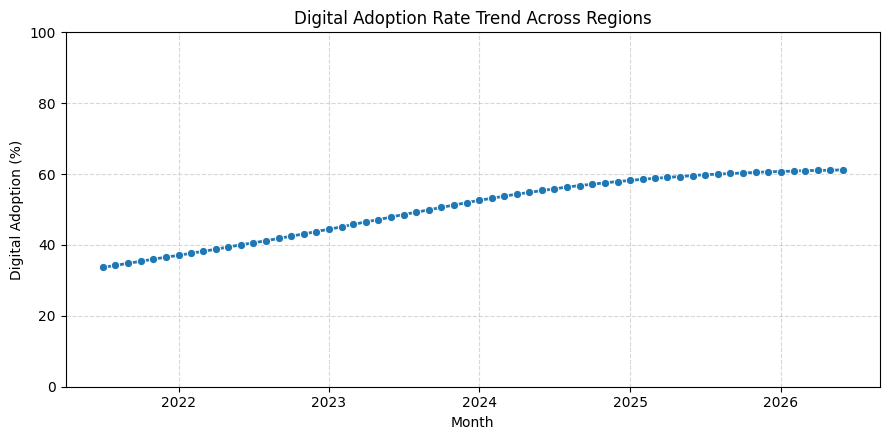

In [9]:
# 1. إزالة تكرار القنوات الأربع وحساب القراءات الفريدة
digital_unique = df[
    ['month', 'region', 'service_category', 'digital_adoption_pct']
].drop_duplicates()

# 2. حساب المتوسط الشهري
monthly_digital = (
    digital_unique.groupby('month')['digital_adoption_pct'].mean().reset_index()
)

# 3. رسم المخطط الخطي
plt.figure(figsize=(9, 4.5))
sns.lineplot(
    data=monthly_digital,
    x='month',
    y='digital_adoption_pct',
    marker='o',
    linewidth=2,
)

plt.title('Digital Adoption Rate Trend Across Regions', fontsize=12)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Digital Adoption (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 100)

# حفظ الصورة الأولى
plt.tight_layout()
plt.savefig('chart1.png', dpi=300)
plt.show()

/tmp/ipykernel_2716/2783355646.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


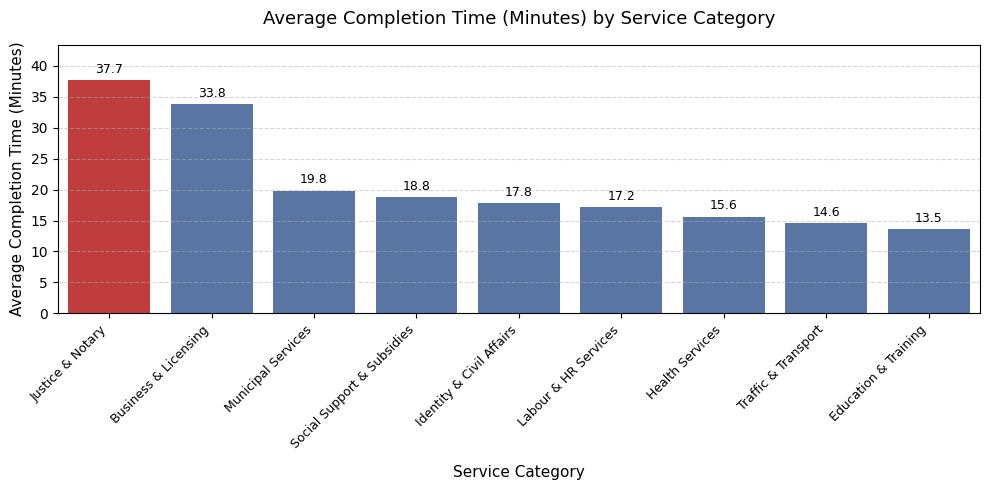

In [10]:
# 1. حساب متوسط زمن الإنجاز بالدقائق لكل فئة خدمة
service_perf = (
    df.groupby('service_category')['avg_completion_min']
    .mean()
    .reset_index()
    .sort_values(by='avg_completion_min', ascending=False)
)

plt.figure(figsize=(10, 5))

colors = [
    '#d62728' if i == 0 else '#4c72b0' for i in range(len(service_perf))
]

ax = sns.barplot(
    data=service_perf,
    x='service_category',
    y='avg_completion_min',
    palette=colors,
)

plt.title(
    'Average Completion Time (Minutes) by Service Category',
    fontsize=13,
    pad=15,
)
plt.xlabel('Service Category', fontsize=11, labelpad=10)
plt.ylabel('Average Completion Time (Minutes)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 3. تدوير الأسماء 45 درجة لعدم التداخل
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(0, service_perf['avg_completion_min'].max() * 1.15)

# 4. كتابة الأرقام فوق الأعمدة
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{height:.1f}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
        fontsize=9,
    )

# حفظ الصورة الثانية
plt.tight_layout()
plt.savefig('chart2.png', dpi=300)
plt.show()